# 6. 数据加载

训练模型需要数据，PyTorch 提供了 Dataset 和 DataLoader 来高效地加载和处理数据。

### 核心概念

- Dataset：定义数据集有哪些数据、如何获取每一条数据
- DataLoader：负责批量加载、打乱顺序、多进程并行读取

可以把 Dataset 想象成一本书，DataLoader 是一个帮你翻书的人——你告诉它每次翻几页（batch_size）、要不要随机翻（shuffle）。

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

## 6.1 自定义 Dataset

要创建自己的数据集，只需继承 Dataset 并实现两个方法：

- __len__()：返回数据集大小
- __getitem__(idx)：返回第 idx 条数据

PyTorch 的 DataLoader 会自动调用这两个方法来加载数据。

In [2]:
class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# 创建模拟数据
data = torch.randn(100, 5)       # 100个样本，每个5维特征
labels = torch.randint(0, 3, (100,))  # 100个标签（0/1/2 三分类）

dataset = MyDataset(data, labels)
print(f"数据集大小: {len(dataset)}")
print(f"第1条数据: {dataset[0]}")
print(f"第1条数据形状: data={dataset[0][0].shape}, label={dataset[0][1]}")

数据集大小: 100
第1条数据: (tensor([ 1.1596, -1.9059, -0.2155, -0.6681, -0.1963]), tensor(0))
第1条数据形状: data=torch.Size([5]), label=0


## 6.2 DataLoader

DataLoader 在 Dataset 之上提供了分批、打乱、多进程等功能。

### 常用参数

- batch_size：每批多少条数据
- shuffle：是否打乱顺序（训练时通常 True，测试时 False）
- num_workers：用几个子进程加载数据（加速读取）

In [3]:
# DataLoader 基本用法
loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"总样本数: {len(dataset)}")
print(f"每批大小: 16")
print(f"总批数: {len(loader)}")  # ceil(100/16) = 7

# 遍历 DataLoader，每次拿一个 batch
print("\n前3个 batch:")
for i, (batch_data, batch_labels) in enumerate(loader):
    if i >= 3:
        break
    print(f"  batch {i}: data形状={batch_data.shape}, labels={batch_labels}")

总样本数: 100
每批大小: 16
总批数: 7

前3个 batch:
  batch 0: data形状=torch.Size([16, 5]), labels=tensor([1, 2, 1, 2, 0, 0, 1, 0, 2, 2, 0, 1, 2, 2, 1, 1])
  batch 1: data形状=torch.Size([16, 5]), labels=tensor([1, 1, 0, 1, 2, 1, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0])
  batch 2: data形状=torch.Size([16, 5]), labels=tensor([0, 0, 1, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 2, 0, 2])


## 6.3 数据增强（torchvision.transforms）

图像任务中，常用数据增强来扩充训练数据，提升模型的泛化能力。

### 什么是数据增强？

对图片做随机变换（翻转、裁剪、旋转等），让模型见到更多样的数据，防止过拟合。

### 常用变换

- Resize：调整大小
- RandomCrop：随机裁剪
- RandomHorizontalFlip：随机水平翻转
- ToTensor：把 PIL 图片转成 Tensor，同时把像素值从 0-255 归一化到 0-1
- Normalize：标准化，让数据均值变为 0、标准差变为 1
- Compose：把多个变换串在一起

In [4]:
from torchvision import transforms

# 训练时的数据增强
train_transform = transforms.Compose([
    transforms.Resize(256),                   # 缩放到 256x256
    transforms.RandomCrop(224),                # 随机裁剪到 224x224
    transforms.RandomHorizontalFlip(p=0.5),     # 50% 概率水平翻转
    transforms.ToTensor(),                      # 转 Tensor，像素值归一化到 0-1
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 标准化参数
                         std=[0.229, 0.224, 0.225])
])

# 测试时不需要随机增强，只做基本的缩放和标准化
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),                # 中心裁剪（确定性的）
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("训练变换:")
for t in train_transform.transforms:
    print(f"  {t}")
print("\n测试变换:")
for t in test_transform.transforms:
    print(f"  {t}")

训练变换:
  Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
  RandomCrop(size=(224, 224), padding=None)
  RandomHorizontalFlip(p=0.5)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

测试变换:
  Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
  CenterCrop(size=(224, 224))
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


## 6.4 预训练数据集

torchvision 内置了常用的数据集，可以直接下载使用。

- MNIST：手写数字（28x28 灰度图，10 类，约 11MB）
- CIFAR10：自然图片（32x32 彩色图，10 类）
- ImageFolder：从文件夹加载自定义图片数据集（按子文件夹分类）

下面以 MNIST 为例演示。

In [5]:
from torchvision import datasets

# 下载 MNIST 手写数字数据集（约 11MB，下载很快）
mnist_train = datasets.MNIST(
    root='./data',         # 保存路径
    train=True,            # 训练集
    download=True,         # 自动下载
    transform=transforms.ToTensor()  # 转 Tensor，像素值归一化到 0-1
)

print(f"MNIST 训练集大小: {len(mnist_train)}")
print(f"类别: {mnist_train.classes}")

# 查看一条数据
img, label = mnist_train[0]
print(f"图片形状: {img.shape}  (C, H, W) 格式")
print(f"标签: {label}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.69MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 162kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.70MB/s]

MNIST 训练集大小: 60000
类别: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
图片形状: torch.Size([1, 28, 28])  (C, H, W) 格式
标签: 5


In [6]:
# 用 DataLoader 加载 MNIST
mnist_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# 取一个 batch 看看
images, labels = next(iter(mnist_loader))
print(f"一个 batch 的图片: {images.shape}")   # (64, 1, 28, 28)
print(f"一个 batch 的标签: {labels.shape}")   # (64,)
print(f"标签值: {labels[:8]}  (前8个)")

一个 batch 的图片: torch.Size([64, 1, 28, 28])
一个 batch 的标签: torch.Size([64])
标签值: tensor([7, 4, 9, 8, 1, 1, 4, 5])  (前8个)


/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDE

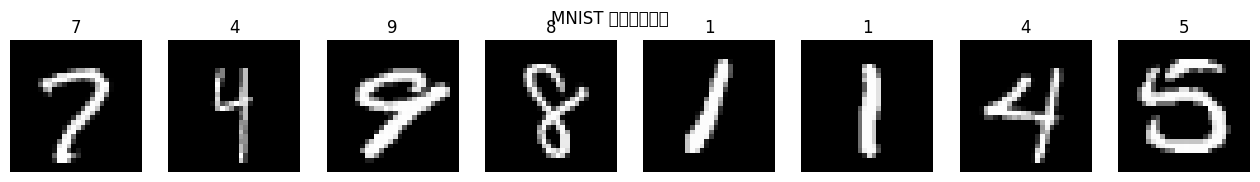

In [8]:
# 可视化 MNIST 图片
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = images[i].squeeze()  # (1, 28, 28) → (28, 28) 去掉通道维
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{labels[i].item()}")
    axes[i].axis('off')
plt.suptitle('MNIST 手写数字样本')
plt.show()

### ImageFolder 用法

当你有自己的图片数据时，按以下目录结构组织：

```
data/
  train/
    cat/        <- 每个类别一个文件夹
      cat1.jpg
      cat2.jpg
    dog/
      dog1.jpg
      dog2.jpg
```

然后用一行代码加载：
```python
dataset = datasets.ImageFolder('data/train', transform=transforms.ToTensor())
```